In [1]:
import pandas as pd
import numpy as np
file_path = '/content/gdrive/MyDrive/Time series Projet/data/merged_tourism_data_final.csv'
# Mount Google Drive if it's not already mounted
from google.colab import drive
drive.mount('/content/gdrive')

df = pd.read_csv(file_path)
df.head()

Mounted at /content/gdrive


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,is_covid,Arrivals,Total_Receipts_MDH
0,1995-01-01,1.469000e+09,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,NaN,0,NaN,1159.279675
1,1995-02-01,1.501953e+09,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,NaN,0,NaN,1159.279675
2,1995-03-01,1.531718e+09,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,NaN,0,NaN,1159.279675
3,1995-04-01,1.564671e+09,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,NaN,0,NaN,1159.279675
4,1995-05-01,1.596562e+09,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,NaN,0,NaN,1159.279675


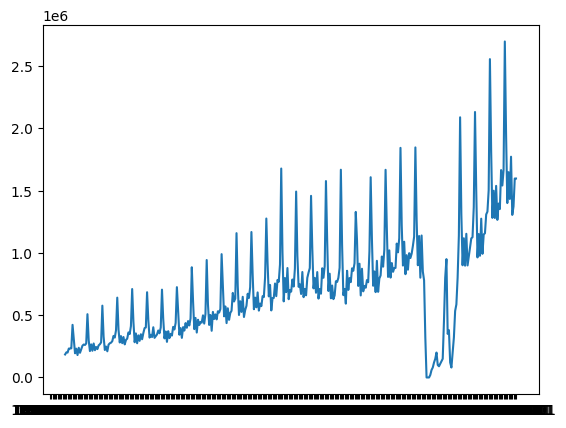

In [2]:
from matplotlib import pyplot as plt
y = df["Arrivals"]
t= df["Date"]
plt.plot(t,y)
plt.show()

### Composition en lags
lag_1 : mois precedent  tendance recente\\
 lag_2 : 2 mois avant  con
rmation de tendance\\
 lag_3 : 3 mois avant  tendance trimestrielle\\
 lag_6 : 6 mois avant  tendance semestielle\\
 lag_12 : meme mois annee precedente  saisonnalite

In [3]:
lags = [1 , 2 ,6 ,12]
for k in lags:
  df[f'lags_{k}']=df['Arrivals'].shift(k)
print("Lags crees :")
print(df[['Date', 'Arrivals', 'lags_1', 'lags_2', 'lags_12']].head(15))

Lags crees :
          Date       Arrivals         lags_1         lags_2  lags_12
0   1995-01-01            NaN            NaN            NaN      NaN
1   1995-02-01            NaN            NaN            NaN      NaN
2   1995-03-01            NaN            NaN            NaN      NaN
3   1995-04-01            NaN            NaN            NaN      NaN
4   1995-05-01            NaN            NaN            NaN      NaN
5   1995-06-01            NaN            NaN            NaN      NaN
6   1995-07-01            NaN            NaN            NaN      NaN
7   1995-08-01            NaN            NaN            NaN      NaN
8   1995-09-01            NaN            NaN            NaN      NaN
9   1995-10-01            NaN            NaN            NaN      NaN
10  1995-11-01            NaN            NaN            NaN      NaN
11  1995-12-01            NaN            NaN            NaN      NaN
12  1996-01-01  184684.480239            NaN            NaN      NaN
13  1996-02-01  20108

###  Rolling Features / Tendance et Volatilite

In [4]:
windows = [3 , 6, 12]
for w in windows :
  # Moyenne mobile ( tendance )
  df[f'roll_mean_{w}'] = (
    df['Arrivals']
    .shift(1) # decaler de 1 pour eviter leakage
    .rolling(window =w)
    .mean())
  # Ecart - type mobile ( volatilite )
  df[f'roll_std_{w}'] = (
    df['Arrivals']
    .shift(1)
    .rolling(window =w)
    .std())

# Taux de croissance annuel ( YoY )
df['growth_yoy'] = (df['Arrivals'] - df['Arrivals'].shift(12)) / \
df['Arrivals'].shift(12) * 100

print("\nRolling features :")
print(df[['Date', 'roll_mean_3', 'roll_mean_12', 'roll_std_6', 'growth_yoy']].tail(10))


Rolling features :
           Date   roll_mean_3  roll_mean_12     roll_std_6  growth_yoy
366  2025-07-01  1.623670e+06  1.571223e+06  168356.020094    5.543194
367  2025-08-01  1.967742e+06  1.583027e+06  496573.449018    7.808449
368  2025-09-01  2.106898e+06  1.594848e+06  476014.035030    9.287090
369  2025-10-01  2.018522e+06  1.604762e+06  467021.898315    9.931526
370  2025-11-01  1.668850e+06  1.617170e+06  468195.329178   11.941056
371  2025-12-01  1.493693e+06  1.629908e+06  482835.868111   15.219509
372  2026-01-01  1.617667e+06  1.649414e+06  478811.656829    3.145992
373  2026-02-01  1.503333e+06  1.652730e+06  250644.102445   -1.660033
374  2026-03-01  1.483333e+06  1.650799e+06  180955.076784   18.120341
375  2026-04-01  1.425000e+06  1.671215e+06  179560.203460   -4.072619


In [5]:
# Conversion de la date en format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extraction des composants temporels
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter

# Encodage cyclique pour le mois
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Fonction pour définir les saisons
def get_season(m):
    if m in [12, 1, 2]: return 0  # Hiver
    elif m in [3, 4, 5]: return 1 # Printemps
    elif m in [6, 7, 8]: return 2 # Été
    else: return 3                # Automne

df['season'] = df['month'].apply(get_season)

# Encodage One-Hot pour la saison
df = pd.get_dummies(df, columns=['season'], prefix='saison', drop_first=True)

print("\nEncodage saisonnier :")
print(df[['Date', 'month', 'month_sin', 'month_cos']].head(14))


Encodage saisonnier :
         Date  month     month_sin     month_cos
0  1995-01-01      1  5.000000e-01  8.660254e-01
1  1995-02-01      2  8.660254e-01  5.000000e-01
2  1995-03-01      3  1.000000e+00  6.123234e-17
3  1995-04-01      4  8.660254e-01 -5.000000e-01
4  1995-05-01      5  5.000000e-01 -8.660254e-01
5  1995-06-01      6  1.224647e-16 -1.000000e+00
6  1995-07-01      7 -5.000000e-01 -8.660254e-01
7  1995-08-01      8 -8.660254e-01 -5.000000e-01
8  1995-09-01      9 -1.000000e+00 -1.836970e-16
9  1995-10-01     10 -8.660254e-01  5.000000e-01
10 1995-11-01     11 -5.000000e-01  8.660254e-01
11 1995-12-01     12 -2.449294e-16  1.000000e+00
12 1996-01-01      1  5.000000e-01  8.660254e-01
13 1996-02-01      2  8.660254e-01  5.000000e-01


### Variable economique

In [6]:
eco_vars = ['Oil_price', 'FDI', 'Poverty_rate', 'GDP_Construction']

for var in eco_vars:
    if var in df.columns:
        # Effet avec 1 mois et 3 mois de retard
        df[f'{var}_lag1'] = df[var].shift(1)
        df[f'{var}_lag3'] = df[var].shift(3)

# Taux de change (si REER est utilisé comme indicateur)
if 'REER' in df.columns:
    df['REER_lag1'] = df['REER'].shift(1)

print("Variables economiques laggees :")
# Affichage des nouvelles colonnes créées
cols_to_show = ['Date'] + [c for c in df.columns if '_lag1' in c]
print(df[cols_to_show].head(6))

Variables economiques laggees :
        Date  Oil_price_lag1      FDI_lag1  Poverty_rate_lag1  \
0 1995-01-01             NaN           NaN                NaN   
1 1995-02-01       17.015000  3.347683e+08          15.500000   
2 1995-03-01       17.050000  3.366899e+08          15.542466   
3 1995-04-01       16.850000  3.384256e+08          15.580822   
4 1995-05-01       18.135738  3.403472e+08          15.623288   
5 1995-06-01       19.380000  3.422068e+08          15.664384   

   GDP_Construction_lag1   REER_lag1  
0                    NaN         NaN  
1                    NaN  109.375670  
2                    NaN  109.404721  
3                    NaN  109.430960  
4                    NaN  109.460011  
5                    NaN  109.488125  


In [7]:
# Initialisation de la colonne
df['cdm_event'] = 0

# Marquage de l'événement (Coupe du Monde 2026)
df.loc[(df['Date'] >= '2025-12-01') & (df['Date'] <= '2026-01-31'), 'cdm_event'] = 1

# Marquage de l'événement (Coupe du Monde 2030)
# Note : On vérifie si les dates existent dans le dataframe avant d'appliquer
df.loc[(df['Date'] >= '2030-06-01') & (df['Date'] <= '2030-07-31'), 'cdm_event'] = 1

# Vérification
print("Dates avec événement CDM détectées :")
print(df[df['cdm_event'] == 1][['Date', 'cdm_event']])

Dates avec événement CDM détectées :
          Date  cdm_event
371 2025-12-01          1
372 2026-01-01          1


### rassemblage des features

In [10]:
FEATURES_ML = [
    # Lags de la cible
    'lags_1', 'lags_2', 'lags_12',
    # Rolling features
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_3', 'roll_std_6', 'roll_std_12', 'growth_yoy',
    # Saisonnalite
    'month_sin', 'month_cos', 'quarter', 'year',
    'saison_1', 'saison_2', 'saison_3',
    # Variables economiques laggees
    'Oil_price_lag1', 'FDI_lag1', 'Poverty_rate_lag1', 'REER_lag1',
    # Dummies evenements
    'is_covid', 'cdm_event'
]

# Verification des colonnes existantes
missing_cols = [c for c in FEATURES_ML if c not in df.columns]
if missing_cols:
    print(f"Attention, colonnes manquantes : {missing_cols}")
else:
    print("Toutes les features sont prêtes !")

Toutes les features sont prêtes !


In [13]:
TARGET = 'Arrivals'

# On recrée df_ml à partir du df original sans supprimer les NaNs des variables économiques
# On garde seulement les lignes où la cible (Arrivals) est présente
df_ml = df.dropna(subset=[TARGET]).copy()

train_end = '2022-12-31'
test_start = '2023-01-01'

# Filtrage des features valides
valid_features = [c for c in FEATURES_ML if c in df_ml.columns]

# Split temporel
X_train = df_ml[df_ml['Date'] <= train_end][valid_features]
y_train = df_ml[df_ml['Date'] <= train_end][TARGET]

X_test = df_ml[df_ml['Date'] >= test_start][valid_features]
y_test = df_ml[df_ml['Date'] >= test_start][TARGET]

print(f"Train : {len(X_train)} lignes (avec NaNs conservés)")
print(f"Test : {len(X_test)} lignes (avec NaNs conservés)")

# Vérification des NaNs dans le test set
print("\nValeurs manquantes dans X_test :")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Train : 324 lignes (avec NaNs conservés)
Test : 40 lignes (avec NaNs conservés)

Valeurs manquantes dans X_test :
Oil_price_lag1       39
FDI_lag1             39
Poverty_rate_lag1    39
REER_lag1            39
dtype: int64


In [14]:
df_ml

,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,...,Oil_price_lag1,Oil_price_lag3,FDI_lag1,FDI_lag3,Poverty_rate_lag1,Poverty_rate_lag3,GDP_Construction_lag1,GDP_Construction_lag3,REER_lag1,cdm_event
12,1996-01-01,1.857000e+09,109.717720,16.98,3.573938e+08,16.0,NaN,1996,1,NaN,...,17.18,16.387705,3.554722e+08,3.516909e+08,15.957534,15.873973,NaN,NaN,109.688669,0
13,1996-02-01,1.839383e+09,109.686163,16.78,4.185424e+08,16.0,NaN,1996,2,NaN,...,16.98,16.530000,3.573938e+08,3.536126e+08,16.000000,15.916438,NaN,NaN,109.717720,0
14,1996-03-01,1.822902e+09,109.656641,18.55,4.757458e+08,16.0,NaN,1996,3,NaN,...,16.78,17.180000,4.185424e+08,3.554722e+08,16.000000,15.957534,NaN,NaN,109.686163,0
15,1996-04-01,1.805284e+09,109.625084,20.80,5.368944e+08,16.0,NaN,1996,4,NaN,...,18.55,16.980000,4.757458e+08,3.573938e+08,16.000000,16.000000,NaN,NaN,109.656641,0
16,1996-05-01,1.788235e+09,109.594545,18.95,5.960704e+08,16.0,NaN,1996,5,NaN,...,20.80,16.780000,5.368944e+08,4.185424e+08,16.000000,16.000000,NaN,NaN,109.625084,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,3617000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
372,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,1,3309000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
373,2026-02-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,2,2993000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
374,2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
import os

# Chemins de sauvegarde pour les sets d'entraînement et de test
folder_path = '/content/gdrive/MyDrive/Time series Projet/data/separted'
path_x_train = f'{folder_path}/X_train.csv'
path_y_train = f'{folder_path}/y_train.csv'
path_x_test = f'{folder_path}/X_test.csv'
path_y_test = f'{folder_path}/y_test.csv'

# Création du dossier s'il n'existe pas
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Dossier créé : {folder_path}")

# Sauvegarde des fichiers (avec NaNs conservés)
X_train.to_csv(path_x_train, index=False)
y_train.to_csv(path_y_train, index=False)
X_test.to_csv(path_x_test, index=False)
y_test.to_csv(path_y_test, index=False)

print("Sauvegarde terminée avec succès dans le dossier 'separted' :")
print(f"- {path_x_train}")
print(f"- {path_y_train}")
print(f"- {path_x_test}")
print(f"- {path_y_test}")